In [ ]:
import numpy as np
import sys
from pathlib import Path

sys.path.insert(0, str(Path().absolute().parent / 'src'))

from models.graphene import SingleLayerGrapheneTB
from utils.kpath import make_k_path


In [4]:
# 无量纲化晶格基矢
model = SingleLayerGrapheneTB(t=2.7)
nb = model.n_bands

high_symmetry_points = []
for high_symmetry in ['Γ', 'M', 'K']:
    high_symmetry_points.append(model.high_symmetry_points()[high_symmetry])

kvec = make_k_path(high_symmetry_points, nkdensity=100)

Nk = len(kvec)
E_k = np.zeros((Nk, nb))
# V_k = np.zeros((Nk, model.n_orbitals, nb), dtype=complex)
for i in range(Nk):
    Ei, _ = model.solve(kvec[i])
    E_k[i] = Ei
    # V_k[i] = Vi


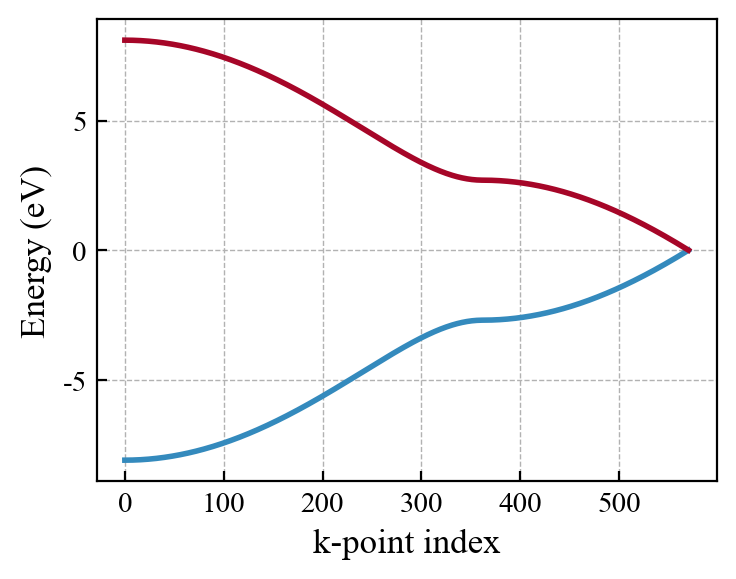

In [5]:
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('bmh')
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 10.5,
    'font.family': ['Times New Roman','SimSun'],#'DejaVu Serif', #
    'axes.unicode_minus': False,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white', # optional: saved figures
    # 'grid.color': '#e0e0e0', # optional: lighter grid
    'axes.edgecolor': 'black', # optional: clearer axes
})

fig, ax = plt.subplots(figsize=(4, 3))
for i in range(nb):
    ax.plot(E_k[:, i], label=f'Band {i+1}')
ax.set_xlabel('k-point index')
ax.set_ylabel('Energy (eV)')
plt.show()